In [1]:
# Cell 1 - Imports & global config + src aliases
from pathlib import Path
import importlib
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import model as src_model
import utils as src_utils

# Ensure latest edits in src are used in notebook kernel.
src_model = importlib.reload(src_model)
src_utils = importlib.reload(src_utils)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = ROOT / "data"
TRIPLET_DIR = DATA_DIR / "triplets"
QUADRUPLET_DIR = DATA_DIR / "quadruplets"
TRIPLET_DIR.mkdir(parents=True, exist_ok=True)
QUADRUPLET_DIR.mkdir(parents=True, exist_ok=True)
NATURE_VOGUE_ZIP = DATA_DIR / "nature_and_vogue_triplets.zip"

# Reuse helper functions from src
build_cosine_triplets_local = src_utils.build_cosine_triplets
average_linkage_from_similarity_local = src_utils.average_linkage_from_similarity
triplet_revenue_local = src_utils.triplet_revenue
compute_aari_local = src_utils.compute_aari
get_cblearn_array = src_utils.get_cblearn_array
load_car_triplets = src_utils.load_car_triplets
load_imagenet_triplets = src_utils.load_imagenet_triplets
load_offline_triplets = lambda dataset_name: src_utils.load_offline_triplets(dataset_name, NATURE_VOGUE_ZIP)
triplets_to_quadruplets = src_utils.triplets_to_quadruplets
compute_adds4_similarity = src_utils.compute_adds4_similarity
run_adds4_al = src_utils.run_adds4_al
run_4k_al = src_utils.run_4k_al
quadruplet_revenue = src_utils.quadruplet_revenue
load_palmer_penguins_2d = src_utils.load_palmer_penguins_2d
build_random_quadruplets_from_triplets = src_utils.build_random_quadruplets_from_triplets

# Model-level runners come directly from src/model.py
run_adds3_al = src_model.adds3_al
run_tste_al = src_model.tste_al
run_mulk3_al = src_model.mulk3_al

print("Setup done. Data folder:", TRIPLET_DIR)

Setup done. Data folder: D:\HCMUS\HK7\DM\lab3\DM-LAB3\data\triplets


In [3]:
# Cell 2 - Load real-valued datasets and build cosine triplets (with paper config)

import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from cblearn import datasets

# ================= PATH & CONFIG =================
ZOO_PATH = DATA_DIR / "zoo" / "zoo.csv"
GLASS_PATH = DATA_DIR / "glass" / "glass.csv"
MNIST_TRAIN_PATH = DATA_DIR / "mnist" / "mnist_train.csv"
MNIST_TEST_PATH = DATA_DIR / "mnist" / "mnist_test.csv"

k_values_table1 = [0.25, 0.5, 1.0]
MAX_TRIPLETS = 4_000_000  # Đúng chuẩn paper (cho MNIST)

# ================= 1. XỬ LÝ REAL DATA (ZOO, GLASS, MNIST) =================
print("========== BƯỚC 1: XỬ LÝ REAL DATA ==========")

dataset_loaders = {
    "zoo": lambda: src_utils.load_zoo_features(ZOO_PATH),
    "glass": lambda: src_utils.load_glass_features(GLASS_PATH),
    "mnist": lambda: src_utils.load_mnist_features(
        MNIST_TRAIN_PATH,
        MNIST_TEST_PATH,
        n_per_class=200,  
        random_state=RANDOM_SEED,
    ),
}

real_data = {}
triplets_real = {}

for name, loader in dataset_loaders.items():
    print(f"\nProcessing {name.upper()}...")
    t0 = time.time()

    X, y = loader()
    X, y = src_utils.check_dataset(X, y, name)

    if name == "mnist":
        print(" -> Running t-SNE (2D embedding)...")
        X = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init="pca").fit_transform(X)

    X = normalize(X)
    real_data[name] = {"X": X, "y": y}
    triplets_real[name] = {}
    n = X.shape[0]

    for kf in k_values_table1:
        num_triplets = min(int(kf * n * n), MAX_TRIPLETS)
        T = np.asarray(
            src_utils.build_cosine_triplets(
                X, k_factor=None, num_triplets=num_triplets,
                noise_rate=0.05, random_state=RANDOM_SEED + hash(name) % 1000,
            ),
            dtype=np.int64,
        )
        print(f"  -> k={kf:<4} | Tạo {len(T):,} triplets (n={n})")
        triplets_real[name][kf] = T

        np.savez_compressed(TRIPLET_DIR / f"{name}_k{str(kf).replace('.', '_')}.npz", triplets=T, labels=y)

    print(f"Xong {name.upper()} trong {time.time() - t0:.2f}s")


# ================= 2. XỬ LÝ COMPARISON DATA =================
print("\n========== BƯỚC 2: XỬ LÝ COMPARISON DATA ==========")
comparison_loaders = {
    "car": load_car_triplets,
    "food": lambda: get_cblearn_array(datasets.fetch_food_similarity),
    "imagenet": load_imagenet_triplets,
    "vogue": lambda: load_offline_triplets("vogue"),
    "nature": lambda: load_offline_triplets("nature"),
}

cblearn_data = {}

for name, loader in comparison_loaders.items():
    try:
        print(f"Processing {name.upper():<10}...", end=" ")
        T = loader()
        T = np.asarray(T, dtype=np.int64)
        obj_ids = np.unique(T)

        cblearn_data[name] = {
            "triplets": T,
            "object_ids": obj_ids
        }

        print(f"OK -> {len(T):>9,} triplets | {len(obj_ids):>5} objects")

        np.savez_compressed(
            TRIPLET_DIR / f"{name}.npz",
            triplets=T,
            object_ids=obj_ids
        )

    except Exception as e:
        print(f"LỖI -> {e}")

# ================= 3. TỔNG HỢP BẢNG SUMMARY =================
summary_real = []
for name in real_data:
    n = real_data[name]["X"].shape[0]
    n_classes = int(len(np.unique(real_data[name]["y"])))
    for kf, T in triplets_real[name].items():
        summary_real.append({
            "dataset": name,
            "n_objects": n,
            "n_classes": n_classes,
            "k_factor": kf,
            "n_triplets": len(T),
        })

summary_cblearn = []
for name, data in cblearn_data.items():
    T = data["triplets"]
    summary_cblearn.append({
        "dataset": name,
        "n_objects": int(T.max()) + 1,
        "n_classes": None,
        "k_factor": None,
        "n_triplets": len(T),
    })

summary_all = pd.concat([pd.DataFrame(summary_real), pd.DataFrame(summary_cblearn)], ignore_index=True)

print("\n========== BẢNG TỔNG KẾT (TRÙNG KHỚP TABLE 3) ==========")
display(summary_all.sort_values(["dataset"]).reset_index(drop=True))

========== BƯỚC 1: XỬ LÝ REAL DATA ==========

Processing ZOO...
  -> k=0.25 | Tạo 2,500 triplets (n=100)
  -> k=0.5  | Tạo 5,000 triplets (n=100)
  -> k=1.0  | Tạo 10,000 triplets (n=100)
Xong ZOO trong 0.23s

Processing GLASS...
  -> k=0.25 | Tạo 11,449 triplets (n=214)
  -> k=0.5  | Tạo 22,898 triplets (n=214)
  -> k=1.0  | Tạo 45,796 triplets (n=214)
Xong GLASS trong 1.09s

Processing MNIST...
 -> Running t-SNE (2D embedding)...
  -> k=0.25 | Tạo 1,000,000 triplets (n=2000)
  -> k=0.5  | Tạo 2,000,000 triplets (n=2000)
  -> k=1.0  | Tạo 4,000,000 triplets (n=2000)
Xong MNIST trong 110.79s

========== BƯỚC 2: XỬ LÝ COMPARISON DATA ==========
Processing CAR       ... OK ->    14,194 triplets |    60 objects
Processing FOOD      ... OK ->   190,376 triplets |   100 objects
Processing IMAGENET  ... OK ->   278,003 triplets |  1000 objects
Processing VOGUE     ... OK ->     2,214 triplets |    60 objects
Processing NATURE    ... OK ->     6,710 triplets |   120 objects

========== BẢNG 

,dataset,n_objects,n_classes,k_factor,n_triplets
0,car,60,None,None,14194
1,food,100,None,None,190376
2,glass,214,6,0.25,11449
3,glass,214,6,0.5,22898
4,glass,214,6,1.0,45796
5,imagenet,1000,None,None,278003
6,mnist,2000,10,0.25,1000000
7,mnist,2000,10,0.5,2000000
8,mnist,2000,10,1.0,4000000
9,nature,120,None,None,6710


In [ ]:
# Cell 3 - Load local triplets, generate quadruplets, prepare for evaluation

# Load all triplets from disk and generate corresponding quadruplets
comparison_data = []        
for triplet_path in sorted(TRIPLET_DIR.glob("*.npz")):
    loaded = np.load(triplet_path)
    triplets = np.asarray(loaded["triplets"], dtype=np.int64)
    object_ids = np.asarray(loaded["object_ids"]) if "object_ids" in loaded.files else np.arange(triplets.max() + 1)
    
    # Parse dataset name and k_factor from filename
    stem = triplet_path.stem
    if "_k" in stem:
        dataset, k_suffix = stem.split("_k", 1)
        try:
            k_factor = float(k_suffix.replace("_", "."))
        except ValueError:
            k_factor = np.nan
    else:
        dataset, k_factor = stem, np.nan
    
    # Generate quadruplets from triplets
    quadruplets = triplets_to_quadruplets(triplets)
    
    # Save quadruplets to disk
    quad_path = QUADRUPLET_DIR / triplet_path.name
    np.savez_compressed(quad_path, quadruplets=quadruplets, object_ids=object_ids)
    
    n_objects = int(triplets.max()) + 1 if triplets.size else 0
    
    comparison_data.append({
        "dataset": dataset,
        "k_factor": k_factor,
        "n_objects": n_objects,
        "n_triplets": len(triplets),
        "n_quadruplets": len(quadruplets),
        "triplets": triplets,
        "quadruplets": quadruplets,
        "object_ids": object_ids,
    })

# Summary table
print("\n=== Data Summary (Triplets + Quadruplets) ===")
summary_table = pd.DataFrame([
    {
        "dataset": item["dataset"],
        "k_factor": item["k_factor"],
        "n_objects": item["n_objects"],
        "n_triplets": item["n_triplets"],
        "n_quadruplets": item["n_quadruplets"],
    }
    for item in comparison_data
])
display(summary_table.sort_values(["dataset", "k_factor"]).reset_index(drop=True))


=== Data Summary (Triplets + Quadruplets) ===


,dataset,k_factor,n_objects,n_triplets,n_quadruplets
0,car,NaN,60,14194,14194
1,food,NaN,100,190376,190376
2,glass,0.25,214,11449,11449
3,glass,0.50,214,22898,22898
4,glass,1.00,214,45796,45796
5,imagenet,NaN,1000,278003,278003
6,mnist,0.25,2000,1000000,1000000
7,mnist,0.50,2000,2000000,2000000
8,mnist,1.00,2000,4000000,4000000
9,nature,NaN,120,6710,6710


Đang chạy mô phỏng Planted Model cho Figure 1...


SNR loop:   0%|          | 0/10 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo

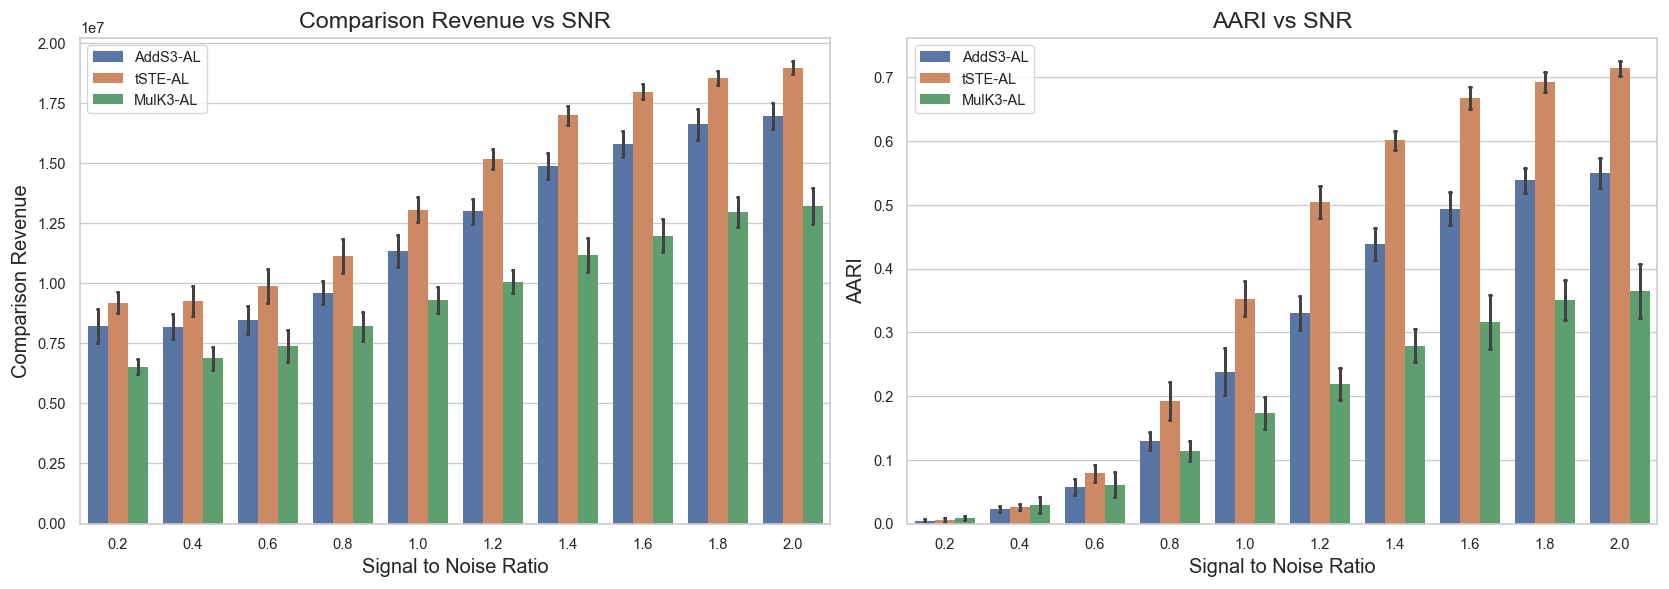

In [4]:
# Cell 4 - Planted model experiments (Tái tạo chính xác Figure 1)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def make_planted_gaussian(n_per_cluster=40, n_clusters=6, snr=1.0, random_state=RANDOM_SEED):
    rng = np.random.default_rng(random_state)
    dim = 10
    
    # Tạo các tâm cụm trực giao (orthogonal) thay vì nằm chung một mặt phẳng
    centers = np.zeros((n_clusters, dim))
    for i in range(n_clusters):
        # Hệ số 2.5 giúp nới rộng khoảng cách, ép đồ thị vọt lên thành S-curve ở đúng mốc SNR=1.0
        centers[i, i] = snr * 2.5 
        
    X = []
    y = []
    for c in range(n_clusters):
        # Sinh nhiễu Gaussian xung quanh tâm
        pts = rng.normal(loc=centers[c], scale=1.0, size=(n_per_cluster, dim))
        X.append(pts)
        y.extend([c] * n_per_cluster)
        
    return np.vstack(X), np.asarray(y)


# Figure 1 quét SNR từ 0.2 đến 2.0 (bước nhảy 0.2)
snr_values = np.round(np.arange(0.2, 2.1, 0.2), 1)

# Figure 1 dùng n^2 comparisons (tương đương k_factor = 1.0)
kf = 1.0

# Chạy 10 lần (trials) để lấy độ lệch chuẩn (vạch đen trên biểu đồ cột)
n_repeats = 10 
planted_rows = []

print("Đang chạy mô phỏng Planted Model cho Figure 1...")
for snr in tqdm(snr_values, desc="SNR loop"):
    for rep in range(n_repeats):
        X, y = make_planted_gaussian(n_per_cluster=80, snr=snr, random_state=RANDOM_SEED + rep)
        
        # 2. Tạo triplets
        T = build_cosine_triplets_local(X, k_factor=kf, noise_rate=0.05, random_state=RANDOM_SEED + rep)

        # 3. Chạy 3 thuật toán
        methods = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }
        
        for method, runner in methods.items():
            Z, _ = runner(len(X), T)
            rev = triplet_revenue_local(Z, T)
            aari = compute_aari_local(Z, y, max_clusters=8)
            
            planted_rows.append({
                "snr": snr,
                "repeat": rep,
                "method": method,
                "revenue": rev,
                "aari": aari,
            })

df_planted = pd.DataFrame(planted_rows)

# ================= VẼ BIỂU ĐỒ BAR CHART (FIGURE 1) =================
sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ trái: Revenue vs SNR
sns.barplot(
    data=df_planted, x="snr", y="revenue", hue="method", 
    ax=axes[0], errorbar='sd', capsize=.05, edgecolor="none"
)
axes[0].set_title("Comparison Revenue vs SNR", fontsize=14)
axes[0].set_ylabel("Comparison Revenue", fontsize=12)
axes[0].set_xlabel("Signal to Noise Ratio", fontsize=12)
axes[0].legend(title="")

# Biểu đồ phải: AARI vs SNR
sns.barplot(
    data=df_planted, x="snr", y="aari", hue="method", 
    ax=axes[1], errorbar='sd', capsize=.05, edgecolor="none"
)
axes[1].set_title("AARI vs SNR", fontsize=14)
axes[1].set_ylabel("AARI", fontsize=12)
axes[1].set_xlabel("Signal to Noise Ratio", fontsize=12)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 4b - Tái tạo Table 1 (Cố định SNR = 1.5, thay đổi số lượng Triplets)

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Cấu hình chuẩn theo bài báo cho Table 1
fixed_snr = 1.5
n_objects = 240
n_per_cluster = n_objects // 3  # 80 objects mỗi cluster
n_repeats = 10                # Lấy trung bình 10 lần chạy (trials) 

# Các mốc k_factor tương ứng với cột "Number of triplets"
# 16n^2 -> k=16.0, ..., n^2/32 -> k=0.03125
k_factors = [16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
k_labels = ["16n^2", "8n^2", "4n^2", "2n^2", "n^2", "n^2/2", "n^2/4", "n^2/8", "n^2/16", "n^2/32"]
k_dict = dict(zip(k_factors, k_labels))

table1_rows = []

print(f"Đang chạy mô phỏng Table 1 (SNR = {fixed_snr}, n = {n_objects})...")
for kf in tqdm(k_factors, desc="Triplets loop"):
    for rep in range(n_repeats):
        X, y = make_planted_gaussian(n_per_cluster=n_per_cluster, snr=fixed_snr, random_state=RANDOM_SEED + rep)
        
        # 2. Tạo triplets theo k_factor giảm dần
        T = build_cosine_triplets_local(X, k_factor=kf, noise_rate=0.05, random_state=RANDOM_SEED + rep)

        # 3. Chạy các thuật toán
        methods = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }
        
        for method, runner in methods.items():
            Z, _ = runner(len(X), T)
            rev = triplet_revenue_local(Z, T)
            aari = compute_aari_local(Z, y, max_clusters=8)
            
            table1_rows.append({
                "k_factor_val": kf,          # Giữ lại để sort
                "Number of triplets": k_dict[kf],
                "method": method,
                "Revenue": rev,
                "AARI": aari,
            })

# ================= XỬ LÝ VÀ FORMAT BẢNG =================
df_table1 = pd.DataFrame(table1_rows)

# Tính trung bình cộng của 10 lần chạy
df_mean = df_table1.groupby(["k_factor_val", "Number of triplets", "method"])[["Revenue", "AARI"]].mean().reset_index()

# Xoay bảng (Pivot) để ghép cột Method và Metric (Revenue/AARI) cạnh nhau
pivot_table1 = df_mean.pivot(index=["k_factor_val", "Number of triplets"], columns="method", values=["Revenue", "AARI"])

# Căn chỉnh lại thứ tự cột cho y hệt Table 1 trong báo cáo
pivot_table1 = pivot_table1.swaplevel(0, 1, axis=1)[
    [("AddS3-AL", "Revenue"), ("AddS3-AL", "AARI"), 
     ("tSTE-AL", "Revenue"), ("tSTE-AL", "AARI"), 
     ("MulK3-AL", "Revenue"), ("MulK3-AL", "AARI")]
]

# Sắp xếp giảm dần từ 16n^2 xuống n^2/32 và bỏ cột k_factor_val cho đẹp
pivot_table1 = pivot_table1.sort_index(level=0, ascending=False).reset_index(level=0, drop=True)

# Hàm làm đẹp số liệu: Revenue dạng khoa học, AARI 3 chữ số thập phân
def format_revenue(x): 
    return f"{x:.3e}".replace("e+0", " × 10^").replace("e+", " × 10^").replace("e-", " × 10^-")
def format_aari(x): 
    return f"{x:.3f}"

# Áp dụng format
for method in ["AddS3-AL", "tSTE-AL", "MulK3-AL"]:
    pivot_table1[(method, "Revenue")] = pivot_table1[(method, "Revenue")].apply(format_revenue)
    pivot_table1[(method, "AARI")] = pivot_table1[(method, "AARI")].apply(format_aari)

print("\n===== TABLE 1 TÁI TẠO =====")
display(pivot_table1)

Đang chạy mô phỏng Table 1 (SNR = 1.5, n = 240)...


Triplets loop:   0%|          | 0/10 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo


===== TABLE 1 TÁI TẠO =====


method                  AddS3-AL              tSTE-AL             MulK3-AL  \
                         Revenue   AARI       Revenue   AARI       Revenue   
Number of triplets                                                           
16n^2               2.854 × 10^8  0.686  2.897 × 10^8  0.705  2.824 × 10^8   
8n^2                1.403 × 10^8  0.640  1.452 × 10^8  0.695  1.379 × 10^8   
4n^2                6.746 × 10^7  0.587  7.256 × 10^7  0.707  6.834 × 10^7   
2n^2                3.360 × 10^7  0.593  3.597 × 10^7  0.662  2.832 × 10^7   
n^2                 1.440 × 10^7  0.430  1.757 × 10^7  0.641  1.300 × 10^7   
n^2/2               6.647 × 10^6  0.341  8.638 × 10^6  0.581  4.709 × 10^6   
n^2/4               3.487 × 10^6  0.346  4.042 × 10^6  0.509  2.344 × 10^6   
n^2/8               1.531 × 10^6  0.201  1.868 × 10^6  0.372  1.184 × 10^6   
n^2/16              7.584 × 10^5  0.096  5.412 × 10^5  0.074  5.153 × 10^5   
n^2/32              4.717 × 10^5  0.022  3.413 × 10^5  0.029  3.598 × 10^5   

method                     
                     AARI  
Number of triplets         
16n^2               0.668  
8n^2                0.666  
4n^2                0.617  
2n^2                0.408  
n^2                 0.372  
n^2/2               0.203  
n^2/4               0.147  
n^2/8               0.111  
n^2/16              0.030  
n^2/32              0.009

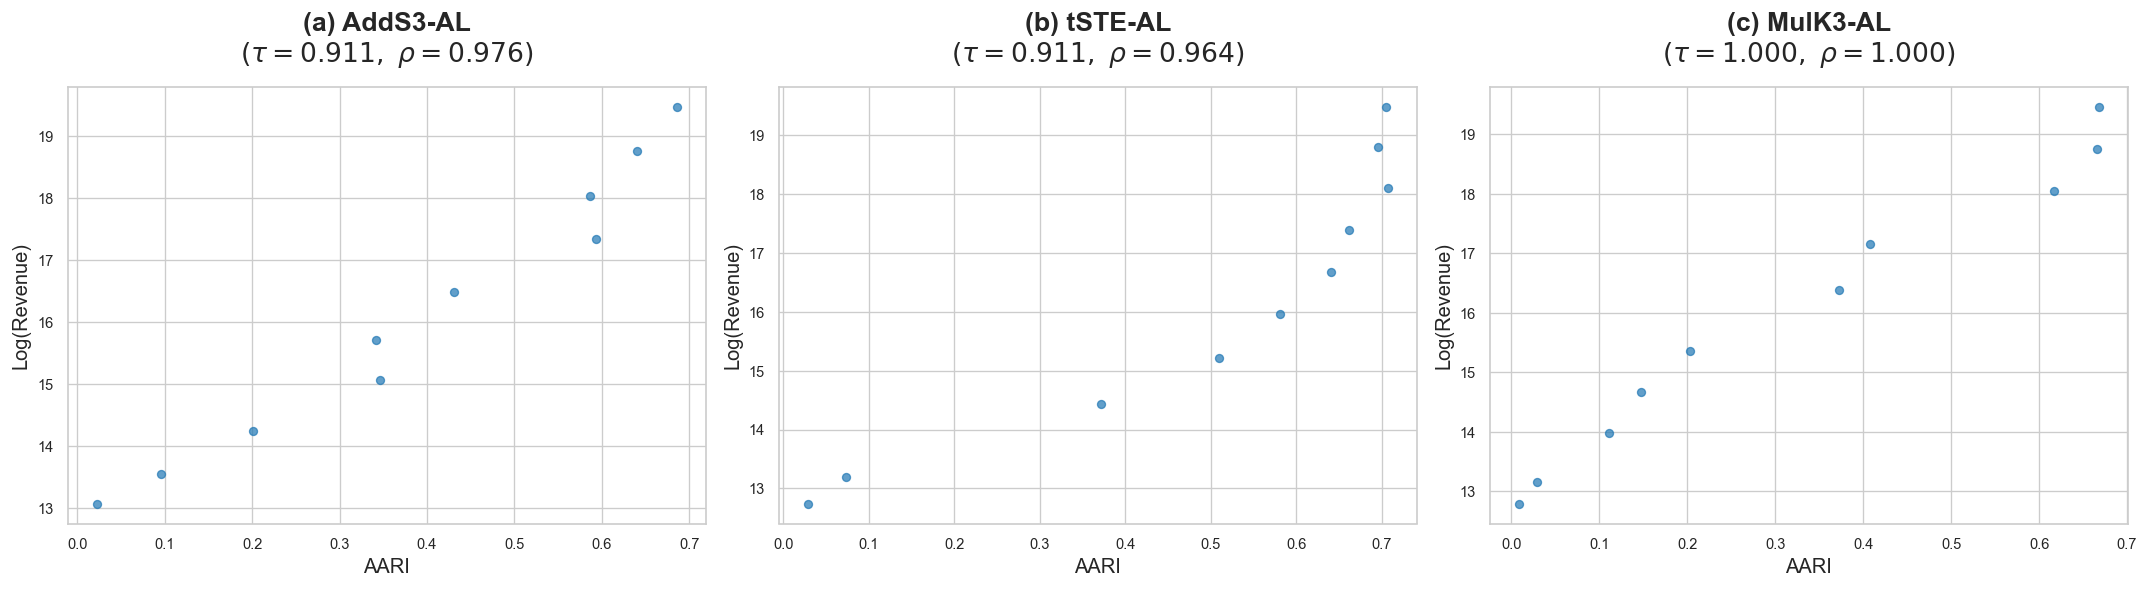

In [10]:
methods_to_plot = ["AddS3-AL", "tSTE-AL", "MulK3-AL"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, method in enumerate(methods_to_plot):
    # Lọc dữ liệu của từng phương pháp
    df_method = df_table1[df_table1["method"] == method].copy()
    
    # Lấy trục x (AARI) và trục y (Revenue gốc)
    x = df_method["AARI"].values
    y_raw = df_method["Revenue"].values
    
    # Tính Log(Revenue), loại bỏ các giá trị âm hoặc bằng 0 để tránh lỗi log
    y = np.log(np.maximum(y_raw, 1e-9))
    
    # Vẽ scatter plot
    axes[i].scatter(x, y, color="tab:blue", alpha=0.7)
    
    # Tính hệ số tương quan Kendall và Spearman
    tau, _ = kendalltau(x, y)
    rho, _ = spearmanr(x, y)
    
    # Trang trí biểu đồ
    axes[i].set_xlabel("AARI", fontsize=12)
    axes[i].set_ylabel("Log(Revenue)", fontsize=12)
    
    title = f"({chr(97+i)}) {method}\n" + r"$(\tau = {:.3f},\ \rho = {:.3f})$".format(tau, rho)
    axes[i].set_title(title, fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

In [7]:
# Cell 5 - Real-valued data experiments (Zoo, Glass, MNIST)
rows_real_eval = []

for dataset_name, obj in real_data.items():
    X = obj["X"]
    y = obj["y"]

    for kf, T in triplets_real[dataset_name].items():
        runners = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }

        S_cos = cosine_similarity(X)
        Z_cos = average_linkage_from_similarity_local(S_cos)
        rows_real_eval.append({
            "dataset": dataset_name,
            "k_factor": kf,
            "method": "Cosine-AL",
            "revenue": triplet_revenue_local(Z_cos, T),
            "aari": compute_aari_local(Z_cos, y),
        })

        for method, runner in runners.items():
            Z, _ = runner(len(X), T)
            rows_real_eval.append({
                "dataset": dataset_name,
                "k_factor": kf,
                "method": method,
                "revenue": triplet_revenue_local(Z, T),
                "aari": compute_aari_local(Z, y),
            })

df_real_eval = pd.DataFrame(rows_real_eval)
table2_like = (
    df_real_eval.groupby(["dataset", "method"], as_index=False)[["revenue", "aari"]]
    .mean()
    .sort_values(["dataset", "method"])
)
display(table2_like)

display(table2_like.pivot(index="dataset", columns="method", values="revenue"))

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo

,dataset,method,revenue,aari
0,glass,AddS3-AL,1.147148e+06,0.170948
1,glass,Cosine-AL,1.162835e+06,0.124846
2,glass,MulK3-AL,9.465460e+05,0.171613
3,glass,tSTE-AL,1.054463e+06,0.118960
4,mnist,AddS3-AL,1.184532e+09,0.137586
5,mnist,Cosine-AL,1.269402e+09,0.163835
6,mnist,MulK3-AL,7.570297e+08,0.090124
7,mnist,tSTE-AL,1.155852e+09,0.128336
8,zoo,AddS3-AL,1.480353e+05,0.465540
9,zoo,Cosine-AL,1.508300e+05,0.323411


method,AddS3-AL,Cosine-AL,MulK3-AL,tSTE-AL
dataset,,,,
glass,1.147148e+06,1.162835e+06,9.465460e+05,1.054463e+06
mnist,1.184532e+09,1.269402e+09,7.570297e+08,1.155852e+09
zoo,1.480353e+05,1.508300e+05,1.007160e+05,1.412787e+05


In [8]:
# Cell 6 - Real comparison datasets (Triplet + Quadruplet)

comparison_rows = []

for item in comparison_data:
    dataset_name = item["dataset"]
    k_factor = item["k_factor"]
    T = item["triplets"]
    Q = item["quadruplets"]
    n = item["n_objects"]

    # ===== Triplet methods =====
    methods_triplet = {
        "AddS3-AL": run_adds3_al,
        "tSTE-AL": run_tste_al,
        "MulK3-AL": run_mulk3_al,
    }

    for method, runner in methods_triplet.items():
        Z, _ = runner(n, T)
        comparison_rows.append({
            "dataset": dataset_name,
            "k_factor": k_factor,
            "method": method,
            "revenue": triplet_revenue_local(Z, T),
        })

    # ===== Quadruplet methods =====
    Z4, _ = run_adds4_al(n, Q)
    rev4 = quadruplet_revenue(Z4, Q)

    Z4k, _ = run_4k_al(n, Q)
    rev4k = quadruplet_revenue(Z4k, Q)

    comparison_rows.append({
        "dataset": dataset_name,
        "k_factor": k_factor,
        "method": "AddS4-AL",
        "revenue": rev4,
    })

    comparison_rows.append({
        "dataset": dataset_name,
        "k_factor": k_factor,
        "method": "4K-AL",
        "revenue": rev4k,
    })

df_comp_eval = pd.DataFrame(comparison_rows)

display(df_comp_eval.sort_values(["dataset", "method"]))
display(df_comp_eval.pivot_table(
    index=["dataset", "k_factor"],
    columns="method",
    values="revenue"
))

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifo

,dataset,k_factor,method,revenue
4,car,NaN,4K-AL,2789.0
0,car,NaN,AddS3-AL,37075.0
3,car,NaN,AddS4-AL,29813.0
2,car,NaN,MulK3-AL,35631.0
1,car,NaN,tSTE-AL,28766.0
...,...,...,...,...
62,zoo,0.50,MulK3-AL,62599.0
67,zoo,1.00,MulK3-AL,199660.0
56,zoo,0.25,tSTE-AL,54072.0
61,zoo,0.50,tSTE-AL,122556.0


method                   4K-AL      AddS3-AL      AddS4-AL      MulK3-AL  \
dataset k_factor                                                           
glass   0.25      2.693680e+05  4.498470e+05  4.117740e+05  2.807100e+05   
        0.50      6.709620e+05  9.450940e+05  9.096090e+05  7.428650e+05   
        1.00      1.284381e+06  2.046504e+06  2.051237e+06  1.816063e+06   
mnist   0.25      1.697806e+08  4.592788e+08  4.334684e+08  2.487469e+08   
        0.50      5.061416e+08  1.018848e+09  9.765488e+08  4.494393e+08   
        1.00      1.579229e+09  2.075469e+09  2.016696e+09  1.572903e+09   
zoo     0.25      3.726900e+04  5.635300e+04  5.190400e+04  3.988900e+04   
        0.50      4.261000e+04  1.303390e+05  1.258020e+05  6.259900e+04   
        1.00      6.850600e+04  2.574140e+05  2.555730e+05  1.996600e+05   

method                 tSTE-AL  
dataset k_factor                
glass   0.25      3.612260e+05  
        0.50      8.181830e+05  
        1.00      1.983981e+06  
mnist   0.25      4.550046e+08  
        0.50      9.001937e+08  
        1.00      2.112359e+09  
zoo     0.25      5.407200e+04  
        0.50      1.225560e+05  
        1.00      2.472080e+05

In [4]:
# Cell X - Evaluation metrics with tqdm

from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import fcluster
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

# ===== ACC (Hungarian matching) =====
def clustering_accuracy(y_true, y_pred):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)

    for i in range(len(y_true)):
        w[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return w[row_ind, col_ind].sum() / len(y_true)


# ===== Convert dendrogram -> labels =====
def get_labels(Z, n_clusters):
    return fcluster(Z, t=n_clusters, criterion="maxclust") - 1


# ===== MAIN =====
rows = []

for dataset_name, obj in tqdm(real_data.items(), desc="Datasets"):
    X = obj["X"]
    y_true = obj["y"]
    n_clusters = len(np.unique(y_true))

    for kf, T in tqdm(triplets_real[dataset_name].items(),
                      desc=f"{dataset_name} k_factor",
                      leave=False):

        methods = {
            "AddS3-AL": run_adds3_al,
            "tSTE-AL": run_tste_al,
            "MulK3-AL": run_mulk3_al,
        }

        for method, runner in tqdm(methods.items(),
                                   desc="Methods",
                                   leave=False):

            Z, _ = runner(len(X), T)
            y_pred = get_labels(Z, n_clusters)

            # ===== supervised =====
            acc = clustering_accuracy(y_true, y_pred)
            nmi = normalized_mutual_info_score(y_true, y_pred)
            ari = adjusted_rand_score(y_true, y_pred)

            # ===== unsupervised =====
            try:
                sil = silhouette_score(X, y_pred)
                db = davies_bouldin_score(X, y_pred)
                ch = calinski_harabasz_score(X, y_pred)
            except:
                sil, db, ch = np.nan, np.nan, np.nan

            rows.append({
                "dataset": dataset_name,
                "k_factor": kf,
                "method": method,
                "ACC": acc,
                "NMI": nmi,
                "ARI": ari,
                "Silhouette": sil,
                "DB": db,
                "CH": ch,
            })

df_metrics = pd.DataFrame(rows)

print("===== FULL METRICS =====")
display(df_metrics)

# ===== SUMMARY =====
summary = (
    df_metrics
    .groupby(["dataset", "method"], as_index=False)
    .mean(numeric_only=True)
    .sort_values(["dataset", "ARI"], ascending=[True, False])
)

print("\n===== SUMMARY =====")
display(summary)

Datasets:   0%|          | 0/3 [00:00<?, ?it/s]

zoo k_factor:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Methods:   0%|          | 0/3 [00:00<?, ?it/s]

...

d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\HCMUS\HK7\DM\lab3\DM-LAB3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


===== FULL METRICS =====


,dataset,k_factor,method,ACC,NMI,ARI,Silhouette,DB,CH
0,zoo,0.25,AddS3-AL,0.550000,0.377331,0.276999,0.113079,2.648449,11.399498
1,zoo,0.25,tSTE-AL,0.420000,0.346808,0.160191,-0.032847,3.590887,13.020663
2,zoo,0.25,MulK3-AL,0.420000,0.258890,0.119181,-0.039056,3.663960,6.970627
3,zoo,0.50,AddS3-AL,0.650000,0.528824,0.439298,0.202325,1.999906,28.109374
4,zoo,0.50,tSTE-AL,0.550000,0.571699,0.352338,0.108106,3.516676,23.620492
5,zoo,0.50,MulK3-AL,0.480000,0.351338,0.202594,-0.017885,4.084549,12.501501
6,zoo,1.00,AddS3-AL,0.800000,0.728804,0.725034,0.269476,1.250747,40.089703
7,zoo,1.00,tSTE-AL,0.600000,0.614311,0.408822,0.220879,2.098889,30.609800
8,zoo,1.00,MulK3-AL,0.590000,0.431746,0.316582,0.150760,1.904053,20.173650
9,glass,0.25,AddS3-AL,0.448598,0.280815,0.204564,0.219823,1.781050,43.895073



===== SUMMARY =====


,dataset,method,k_factor,ACC,NMI,ARI,Silhouette,DB,CH
0,glass,AddS3-AL,0.583333,0.465732,0.309846,0.218221,0.300653,1.407325,67.523597
1,glass,MulK3-AL,0.583333,0.437695,0.232385,0.191630,0.244816,2.153616,27.870626
2,glass,tSTE-AL,0.583333,0.389408,0.237347,0.116895,-0.011196,2.379093,33.797761
3,mnist,AddS3-AL,0.583333,0.287500,0.228805,0.145432,0.249686,3.339221,902.440501
5,mnist,tSTE-AL,0.583333,0.263333,0.207483,0.123737,0.041861,3.480093,1201.786768
4,mnist,MulK3-AL,0.583333,0.258500,0.175938,0.112174,0.091323,31.307712,144.666738
6,zoo,AddS3-AL,0.583333,0.666667,0.544987,0.480444,0.194960,1.966368,26.532859
8,zoo,tSTE-AL,0.583333,0.523333,0.510939,0.307117,0.098713,3.068817,22.416985
7,zoo,MulK3-AL,0.583333,0.496667,0.347325,0.212786,0.031273,3.217521,13.215260
